In [1]:
import pandas as pd

df = pd.read_csv('cleaned_tweets.csv')

# Drop any rows where clean_text is empty/null
df = df.dropna(subset=['clean_text'])

print("Shape:", df.shape)
print("\nSentiment counts:")
print(df['airline_sentiment'].value_counts())

Shape: (14614, 3)

Sentiment counts:
airline_sentiment
negative    9172
neutral     3083
positive    2359
Name: count, dtype: int64


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)  # use top 5000 words only

X = vectorizer.fit_transform(df['clean_text'])
y = df['airline_sentiment']

print("X shape:", X.shape)  # should be (14614, 5000)
print("y shape:", y.shape)  # should be (14614,)

X shape: (14614, 5000)
y shape: (14614,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 11691
Testing samples:  2923


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
lr_preds = lr_model.predict(X_test)

# Evaluate
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("\nDetailed Report:")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy: 0.7745466985973315

Detailed Report:
              precision    recall  f1-score   support

    negative       0.79      0.93      0.86      1811
     neutral       0.67      0.46      0.55       643
    positive       0.80      0.59      0.68       469

    accuracy                           0.77      2923
   macro avg       0.75      0.66      0.69      2923
weighted avg       0.77      0.77      0.76      2923



In [5]:
from sklearn.naive_bayes import MultinomialNB

# Train
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict
nb_preds = nb_model.predict(X_test)

# Evaluate
print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, nb_preds))
print("\nDetailed Report:")
print(classification_report(y_test, nb_preds))

=== Naive Bayes ===
Accuracy: 0.7242559014710913

Detailed Report:
              precision    recall  f1-score   support

    negative       0.71      0.99      0.83      1811
     neutral       0.79      0.24      0.37       643
    positive       0.85      0.38      0.52       469

    accuracy                           0.72      2923
   macro avg       0.78      0.53      0.57      2923
weighted avg       0.75      0.72      0.68      2923



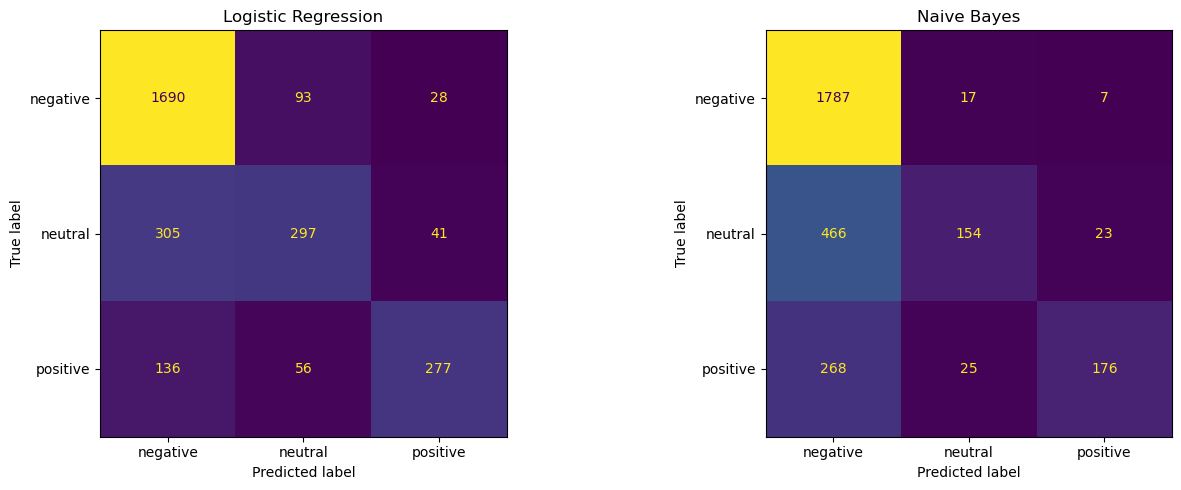

Saved as confusion_matrix.png


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes, 
                             [lr_preds, nb_preds], 
                             ['Logistic Regression', 'Naive Bayes']):
    cm = confusion_matrix(y_test, preds, labels=['negative', 'neutral', 'positive'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['negative', 'neutral', 'positive'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Saved as confusion_matrix.png")

In [8]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0
